# HW14 – Эмбеддинги, FAISS, оценка retrieval и mini-RAG

## Тема базы знаний: Солнечная система

## 1. Импорты, seed и среда

In [28]:

import json
import os
import re
import sys
import random
import subprocess
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer

os.environ["TOKENIZERS_PARALLELISM"] = "false"


def ensure_package(package_name: str, import_name: Optional[str] = None) -> None:
    target = import_name or package_name
    try:
        __import__(target)
    except Exception:
        print(f"Устанавливаем пакет: {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])


ensure_package("faiss-cpu", "faiss")
ensure_package("sentence-transformers", "sentence_transformers")


try:
    import faiss
    FAISS_AVAILABLE = True
except Exception as e:
    FAISS_AVAILABLE = False
    print("FAISS недоступен:", repr(e))


print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("FAISS available:", FAISS_AVAILABLE)

NumPy: 2.3.5
Pandas: 2.3.3
FAISS available: True


In [55]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)


set_seed(42)

try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

print("Устройство для работы:", DEVICE)
print("FAISS доступен:", FAISS_AVAILABLE)
print(f"torch: {torch.__version__}")

Устройство для работы: cpu
FAISS доступен: True
torch: 2.10.0+cpu


## 2. База знаний и первичный анализ


In [30]:
KB_PATH = "knowledge_base.json"

with open(KB_PATH, "r", encoding="utf-8") as f:
    documents: List[Dict[str, str]] = json.load(f)

docs_df = pd.DataFrame(documents)
print(f"Количество документов: {len(docs_df)}")
print(f"Поля: {list(docs_df.columns)}")
print()
display(docs_df[["doc_id", "title"]])

Количество документов: 15
Поля: ['doc_id', 'title', 'text']



,doc_id,title
0,doc_01,Солнце
1,doc_02,Меркурий
2,doc_03,Венера
3,doc_04,Земля
4,doc_05,Луна
5,doc_06,Марс
6,doc_07,Юпитер
7,doc_08,Сатурн
8,doc_09,Уран
9,doc_10,Нептун


In [31]:
# 5 примеров документов.
for doc in documents[:5]:
    display(Markdown(f"**{doc['doc_id']} – {doc['title']}**"))
    print(doc["text"])
    print()

**doc_01 – Солнце**

Солнце – это звезда в центре Солнечной системы. Оно состоит в основном из водорода и гелия. Температура на поверхности Солнца составляет около 5500 градусов Цельсия, а в ядре достигает 15 миллионов градусов. Солнце обеспечивает энергию для жизни на Земле благодаря термоядерным реакциям, в ходе которых водород превращается в гелий. Масса Солнца составляет около 99,86 процентов всей массы Солнечной системы. Солнечный ветер – поток заряженных частиц – распространяется далеко за орбиту Плутона. На Солнце в 2026 году образовалась корональная дыра в 20 раз больше Земли. Коронарная дыра – это область на Солнце, где магнитное поле открыто, что приводит к выходу заряженных частиц в космическое пространство. Коронарные дыры могут быть опасны для нашей технологической инфраструктуры и спутников из-за высокоэнергичных частиц, которые они испускают. Эти частицы могут вызывать сильные геомагнитные бури, которые могут повредить электрические сети, спутники связи, а также вызвать аварии на космических

**doc_02 – Меркурий**

Меркурий – ближайшая к Солнцу планета и самая маленькая в Солнечной системе. У Меркурия практически нет атмосферы, поэтому перепады температуры на поверхности огромны: от минус 180 градусов ночью до плюс 430 градусов днём. Один оборот вокруг Солнца Меркурий совершает за 88 земных дней. Поверхность Меркурия покрыта кратерами и напоминает лунную. Меркурий исследовался аппаратами Mariner 10 и MESSENGER. Меркурий зимой покрывается железным снегом. Выяснилось, что у этой планеты есть собственная магнитосфера, а зимой здесь выпадают необычные осадки в виде железного снега. Магнитное поле Земли примерно в 100 раз сильнее, чем магнитное поле Меркурия. Существованию планеты помогает ядро, состоящее из жидкости, способной вырабатывать необходимое количество тепла. Поскольку поле Меркурия не отличается достаточной силой, в холодную пору на планету выпадают заряженные от светила радиоактивные частицы, которые сохраняют свой вид в виде серы и железного снега. В случае, если Земля ослабеет так же, к

**doc_03 – Венера**

Венера – вторая планета от Солнца, по размеру и массе близкая к Земле. Однако условия на Венере крайне суровы: плотная атмосфера из углекислого газа создаёт мощный парниковый эффект, из-за которого температура на поверхности достигает 470 градусов. Атмосферное давление на поверхности Венеры примерно в 90 раз выше земного. Венера вращается в направлении, противоположном большинству планет, и один оборот вокруг своей оси занимает 243 земных дня – дольше, чем один оборот вокруг Солнца. Венера — третий по яркости объект на небе Земли после Солнца и Луны и достигает видимой звёздной величины в −4,6. Поскольку Венера ближе к Солнцу, чем Земля, она никогда не удаляется от Солнца более чем на 47,8° (для земного наблюдателя). Своей максимальной яркости Венера достигает незадолго до восхода или через некоторое время после захода Солнца, что дало повод называть её также Вечерняя звезда или Утренняя звезда. В глубокой древности Венера, как полагают, настолько разогрелась, что подобные земным океан

**doc_04 – Земля**

Земля – третья планета от Солнца и единственная известная планета, на которой существует жизнь. Около 71 процента поверхности Земли покрыто водой. Атмосфера Земли состоит преимущественно из азота и кислорода. Магнитное поле Земли защищает планету от солнечного ветра и космической радиации. Земля имеет один естественный спутник – Луну, которая влияет на приливы и отливы в океанах. Средний радиус Земли составляет около 6371 километра.



**doc_05 – Луна**

Луна – единственный естественный спутник Земли. Она находится на среднем расстоянии около 384 400 километров от Земли. Луна не имеет атмосферы и магнитного поля. Поверхность Луны покрыта кратерами и слоем реголита. Луна всегда обращена к Земле одной стороной из-за приливного захвата. Первые люди побывали на Луне в 1969 году в рамках миссии Аполлон-11. На Луне обнаружены запасы водяного льда в полярных кратерах.



In [60]:
# Базовая статистика по документам.
docs_df["n_words"] = docs_df["text"].apply(lambda t: len(t.split()))
docs_df["n_chars"] = docs_df["text"].apply(len)

print("Статистика по длине документов (в словах):")
print(f"  мин: {docs_df['n_words'].min()}, макс: {docs_df['n_words'].max()}, среднее: {docs_df['n_words'].mean():.0f}")
print(f"  всего слов: {docs_df['n_words'].sum()}")

Статистика по длине документов (в словах):
  мин: 54, макс: 189, среднее: 85
  всего слов: 1281


**Предметная область:** Солнечная система – планеты, спутники, малые тела и космические миссии.  
**Почему подходит для retrieval:** каждый документ содержит уникальные факты о конкретном объекте. Вопросы по этой теме имеют чёткие ответы, которые можно найти в конкретных документах, что позволяет объективно оценивать качество поиска.

## 3. Чанкинг документов

Разбиваем каждый документ на небольшие фрагменты (чанки) по словам с перекрытием (overlap).

In [33]:

def chunk_text(text: str, chunk_size: int = 30, overlap: int = 8) -> List[str]:
    words = text.replace("\n", " ").split()

    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")

    chunks = []
    step = chunk_size - overlap

    for start in range(0, len(words), step):
        chunk_words = words[start : start + chunk_size]
        if not chunk_words:
            continue
        chunks.append(" ".join(chunk_words))
        if start + chunk_size >= len(words):
            break

    return chunks


def build_chunks_dataframe(
    docs: List[Dict[str, str]],
    chunk_size: int = 30,
    overlap: int = 8,
) -> pd.DataFrame:
    rows = []
    for doc in docs:
        chunks = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_idx, chunk in enumerate(chunks):
            rows.append({
                "doc_id": doc["doc_id"],
                "title": doc["title"],
                "chunk_idx": chunk_idx,
                "chunk_text": chunk,
                "n_words": len(chunk.split()),
            })
    return pd.DataFrame(rows)


CHUNK_SIZE = 30
OVERLAP = 8

chunks_df = build_chunks_dataframe(documents, chunk_size=CHUNK_SIZE, overlap=OVERLAP)

print(f"Количество чанков: {len(chunks_df)}")
print(f"Параметры: chunk_size={CHUNK_SIZE}, overlap={OVERLAP}")
display(chunks_df.head(10))

Количество чанков: 61
Параметры: chunk_size=30, overlap=8


,doc_id,title,chunk_idx,chunk_text,n_words
0,doc_01,Солнце,0,Солнце – это звезда в центре Солнечной системы...,30
1,doc_01,Солнце,1,"5500 градусов Цельсия, а в ядре достигает 15 м...",30
2,doc_01,Солнце,2,которых водород превращается в гелий. Масса Со...,30
3,doc_01,Солнце,3,распространяется далеко за орбиту Плутона. На ...,30
4,doc_01,Солнце,4,"область на Солнце, где магнитное поле открыто,...",30
5,doc_01,Солнце,5,нашей технологической инфраструктуры и спутник...,30
6,doc_01,Солнце,6,"сети, спутники связи, а также вызвать аварии н...",30
7,doc_01,Солнце,7,"GPS-навигации и других технологий, которые зав...",30
8,doc_01,Солнце,8,"астронавтов, работающих в космосе, и для людей...",11
9,doc_02,Меркурий,0,Меркурий – ближайшая к Солнцу планета и самая ...,30


In [34]:
example_doc = documents[0]
display(Markdown(f"### Пример чанкинга документа: **{example_doc['title']}**"))
print(f"Исходный текст ({len(example_doc['text'].split())} слов):")
print(example_doc["text"])
print()

example_chunks = chunk_text(example_doc["text"], chunk_size=CHUNK_SIZE, overlap=OVERLAP)
for i, chunk in enumerate(example_chunks):
    print(f"  Чанк {i}: [{len(chunk.split())} слов] {chunk}")
    print()

### Пример чанкинга документа: **Солнце**

Исходный текст (187 слов):
Солнце – это звезда в центре Солнечной системы. Оно состоит в основном из водорода и гелия. Температура на поверхности Солнца составляет около 5500 градусов Цельсия, а в ядре достигает 15 миллионов градусов. Солнце обеспечивает энергию для жизни на Земле благодаря термоядерным реакциям, в ходе которых водород превращается в гелий. Масса Солнца составляет около 99,86 процентов всей массы Солнечной системы. Солнечный ветер – поток заряженных частиц – распространяется далеко за орбиту Плутона. На Солнце в 2026 году образовалась корональная дыра в 20 раз больше Земли. Коронарная дыра – это область на Солнце, где магнитное поле открыто, что приводит к выходу заряженных частиц в космическое пространство. Коронарные дыры могут быть опасны для нашей технологической инфраструктуры и спутников из-за высокоэнергичных частиц, которые они испускают. Эти частицы могут вызывать сильные геомагнитные бури, которые могут повредить электрические сети, спутники связи, а также вы

## 4. Эмбеддинги и индекс FAISS

Используется multilingual-модель `paraphrase-multilingual-MiniLM-L12-v2` из `sentence-transformers`.
Она хорошо работает с русским языком и выдаёт нормализованные 384-мерные векторы.
Для индекса используется `FAISS IndexFlatIP` — точный поиск по скалярному произведению (= косинусное сходство для нормализованных векторов).

In [35]:

class EmbeddingBackend:
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError


class SentenceTransformersBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: str = "cpu") -> None:
        from sentence_transformers import SentenceTransformer

        self.model_name = model_name
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f"SentenceTransformer: {model_name}"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts, batch_size=16, show_progress_bar=False,
            convert_to_numpy=True, normalize_embeddings=True,
        )
        return vectors.astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts, batch_size=16, show_progress_bar=False,
            convert_to_numpy=True, normalize_embeddings=True,
        )
        return vectors.astype("float32")


class TfidfFallbackBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2))
        self.backend_name = "TF-IDF fallback"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.fit_transform(texts).toarray().astype("float32")
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.transform(texts).toarray().astype("float32")
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms


def select_backend(device: str = "cpu") -> EmbeddingBackend:
    try:
        backend = SentenceTransformersBackend(
            model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
            device=device,
        )
        print("Используем dense-модель эмбеддингов.")
        print("Бэкэнд:", backend.backend_name)
        return backend
    except Exception as e:
        print("Dense-модель недоступна, переключаемся на TF-IDF fallback.")
        print("Причина:", repr(e))
        return TfidfFallbackBackend()

In [36]:
# Retriever: собираем все артефакты в одну структуру.
@dataclass
class RetrievalArtifacts:
    backend_name: str
    backend: EmbeddingBackend
    chunks_df: pd.DataFrame
    chunk_vectors: np.ndarray
    index: object


def build_retriever(
    docs: List[Dict[str, str]],
    chunk_size: int = 30,
    overlap: int = 8,
    device: str = "cpu",
) -> RetrievalArtifacts:
    chunks_df = build_chunks_dataframe(docs, chunk_size=chunk_size, overlap=overlap)
    backend = select_backend(device=device)
    chunk_vectors = backend.fit_documents(chunks_df["chunk_text"].tolist())

    index = faiss.IndexFlatIP(chunk_vectors.shape[1])
    index.add(chunk_vectors)

    return RetrievalArtifacts(
        backend_name=backend.backend_name,
        backend=backend,
        chunks_df=chunks_df,
        chunk_vectors=chunk_vectors,
        index=index,
    )


def search_chunks(
    query: str,
    artifacts: RetrievalArtifacts,
    top_k: int = 5,
) -> pd.DataFrame:
    query_vector = artifacts.backend.encode_queries([query]).astype("float32")
    scores, indices = artifacts.index.search(query_vector, top_k)

    rows = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        chunk_row = artifacts.chunks_df.iloc[int(idx)]
        rows.append({
            "rank": rank,
            "score": round(float(score), 4),
            "doc_id": chunk_row["doc_id"],
            "title": chunk_row["title"],
            "chunk_idx": int(chunk_row["chunk_idx"]),
            "chunk_text": chunk_row["chunk_text"],
        })
    return pd.DataFrame(rows)

In [37]:
artifacts = build_retriever(
    documents,
    chunk_size=CHUNK_SIZE,
    overlap=OVERLAP,
    device=DEVICE,
)

print("Бэкэнд:", artifacts.backend_name)
print("Количество чанков:", len(artifacts.chunks_df))
print("Размерность эмбеддингов:", artifacts.chunk_vectors.shape[1])

# Проверяем нормализацию.
norms = np.linalg.norm(artifacts.chunk_vectors, axis=1)
print(f"Нормы векторов: min={norms.min():.4f}, max={norms.max():.4f} → нормировка OK")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3127.71it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.
Бэкэнд: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Бэкэнд: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Количество чанков: 61
Размерность эмбеддингов: 384
Нормы векторов: min=1.0000, max=1.0000 → нормировка OK


In [38]:
example_queries = [
    "Какая температура на поверхности Солнца?",
    "Какая планета самая большая в Солнечной системе?",
    "Когда люди впервые побывали на Луне?",
    "Из чего состоят кольца Сатурна?",
    "Какой аппарат исследовал Плутон?",
]

for q in example_queries:
    display(Markdown(f"### Запрос: `{q}`"))
    display(search_chunks(q, artifacts=artifacts, top_k=3))

### Запрос: `Какая температура на поверхности Солнца?`

,rank,score,doc_id,title,chunk_idx,chunk_text
0,1,0.7846,doc_01,Солнце,0,Солнце – это звезда в центре Солнечной системы...
1,2,0.6457,doc_01,Солнце,1,"5500 градусов Цельсия, а в ядре достигает 15 м..."
2,3,0.5642,doc_02,Меркурий,1,огромны: от минус 180 градусов ночью до плюс 4...


### Запрос: `Какая планета самая большая в Солнечной системе?`

,rank,score,doc_id,title,chunk_idx,chunk_text
0,1,0.7742,doc_07,Юпитер,0,Юпитер – пятая планета от Солнца и крупнейшая ...
1,2,0.7544,doc_07,Юпитер,2,"Ио, Европа, Ганимед и Каллисто. Ганимед – круп..."
2,3,0.6872,doc_08,Сатурн,2,"воде, если бы существовал достаточно большой о..."


### Запрос: `Когда люди впервые побывали на Луне?`

,rank,score,doc_id,title,chunk_idx,chunk_text
0,1,0.7200,doc_05,Луна,1,магнитного поля. Поверхность Луны покрыта крат...
1,2,0.5920,doc_05,Луна,2,на Луне в 1969 году в рамках миссии Аполлон-11...
2,3,0.5574,doc_05,Луна,0,Луна – единственный естественный спутник Земли...


### Запрос: `Из чего состоят кольца Сатурна?`

,rank,score,doc_id,title,chunk_idx,chunk_text
0,1,0.7748,doc_08,Сатурн,0,"Сатурн – шестая планета от Солнца, известная с..."
1,2,0.5671,doc_15,Формирование Солнечной системы,1,"Солнце, а из оставшегося вещества – протоплане..."
2,3,0.5379,doc_15,Формирование Солнечной системы,2,"(Юпитер, Сатурн, Уран, Нептун) – газовые и лед..."


### Запрос: `Какой аппарат исследовал Плутон?`

,rank,score,doc_id,title,chunk_idx,chunk_text
0,1,0.6598,doc_14,Космические миссии к планетам,0,Исследование Солнечной системы ведётся с помощ...
1,2,0.6362,doc_13,Плутон и пояс Койпера,1,планеты. Плутон находится в поясе Койпера – об...
2,3,0.6254,doc_13,Плутон и пояс Койпера,0,Плутон был открыт в 1930 году и долгое время с...


## 5. Контрольные запросы и оценка retrieval

In [39]:
# Набор контрольных запросов с ожидаемыми релевантными документами.
benchmark_queries: List[Dict[str, object]] = [
    {
        "query_id": "q01",
        "query": "Какова температура на поверхности и в ядре Солнца?",
        "relevant_doc_ids": ["doc_01"],
    },
    {
        "query_id": "q02",
        "query": "Почему на Меркурии такие большие перепады температуры?",
        "relevant_doc_ids": ["doc_02"],
    },
    {
        "query_id": "q03",
        "query": "Чем вызван парниковый эффект на Венере?",
        "relevant_doc_ids": ["doc_03"],
    },
    {
        "query_id": "q04",
        "query": "Какой процент поверхности Земли покрыт водой?",
        "relevant_doc_ids": ["doc_04"],
    },
    {
        "query_id": "q05",
        "query": "Когда состоялась первая высадка людей на Луну?",
        "relevant_doc_ids": ["doc_05"],
    },
    {
        "query_id": "q06",
        "query": "Какой самый большой вулкан в Солнечной системе и где он находится?",
        "relevant_doc_ids": ["doc_06"],
    },
    {
        "query_id": "q07",
        "query": "Сколько спутников у Юпитера и какие из них самые известные?",
        "relevant_doc_ids": ["doc_07"],
    },
    {
        "query_id": "q08",
        "query": "Из чего состоят кольца Сатурна?",
        "relevant_doc_ids": ["doc_08"],
    },
    {
        "query_id": "q09",
        "query": "Почему Плутон больше не считается планетой?",
        "relevant_doc_ids": ["doc_13"],
    },
    {
        "query_id": "q10",
        "query": "Какие аппараты Voyager изучали внешние планеты?",
        "relevant_doc_ids": ["doc_14"],
    },
]

print(f"Контрольных запросов: {len(benchmark_queries)}")
display(pd.DataFrame(benchmark_queries)[["query_id", "query", "relevant_doc_ids"]])

Контрольных запросов: 10


,query_id,query,relevant_doc_ids
0,q01,Какова температура на поверхности и в ядре Сол...,[doc_01]
1,q02,Почему на Меркурии такие большие перепады темп...,[doc_02]
2,q03,Чем вызван парниковый эффект на Венере?,[doc_03]
3,q04,Какой процент поверхности Земли покрыт водой?,[doc_04]
4,q05,Когда состоялась первая высадка людей на Луну?,[doc_05]
5,q06,Какой самый большой вулкан в Солнечной системе...,[doc_06]
6,q07,Сколько спутников у Юпитера и какие из них сам...,[doc_07]
7,q08,Из чего состоят кольца Сатурна?,[doc_08]
8,q09,Почему Плутон больше не считается планетой?,[doc_13]
9,q10,Какие аппараты Voyager изучали внешние планеты?,[doc_14]


In [40]:
# Функции для оценки retrieval.
def unique_doc_order(result_df: pd.DataFrame) -> List[str]:
    """Уникальные doc_id в порядке появления в результатах поиска."""
    seen = set()
    ordered = []
    for doc_id in result_df["doc_id"].tolist():
        if doc_id not in seen:
            seen.add(doc_id)
            ordered.append(doc_id)
    return ordered


def evaluate_query(
    query: str,
    relevant_doc_ids: List[str],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> Dict[str, object]:
    result_df = search_chunks(query, artifacts=artifacts, top_k=top_k)
    predicted_doc_ids = unique_doc_order(result_df)

    hit = int(any(d in predicted_doc_ids for d in relevant_doc_ids))
    recall = sum(d in predicted_doc_ids for d in relevant_doc_ids) / len(relevant_doc_ids)

    first_relevant_rank = None
    for idx, doc_id in enumerate(predicted_doc_ids, start=1):
        if doc_id in relevant_doc_ids:
            first_relevant_rank = idx
            break
    mrr = 0.0 if first_relevant_rank is None else 1.0 / first_relevant_rank

    return {
        "predicted_doc_ids": predicted_doc_ids,
        "hit": hit,
        "recall": recall,
        "first_relevant_rank": first_relevant_rank,
        "mrr": mrr,
        "result_df": result_df,
    }


def evaluate_benchmark(
    benchmark_rows: List[Dict[str, object]],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    rows = []
    for row in benchmark_rows:
        metrics = evaluate_query(
            query=row["query"],
            relevant_doc_ids=row["relevant_doc_ids"],
            artifacts=artifacts,
            top_k=top_k,
        )
        rows.append({
            "query_id": row["query_id"],
            "query": row["query"],
            "relevant_doc_ids": ", ".join(row["relevant_doc_ids"]),
            "predicted_doc_ids": ", ".join(metrics["predicted_doc_ids"]),
            f"hit@{top_k}": metrics["hit"],
            f"recall@{top_k}": metrics["recall"],
            f"MRR@{top_k}": metrics["mrr"],
            "first_relevant_rank": metrics["first_relevant_rank"],
        })
    return pd.DataFrame(rows)

In [41]:
# Оценка retrieval на контрольных запросах (top_k=3).
TOP_K = 3
eval_df = evaluate_benchmark(benchmark_queries, artifacts=artifacts, top_k=TOP_K)
display(eval_df)

# Сводка метрик.
summary = pd.DataFrame({
    "metric": [f"mean_hit@{TOP_K}", f"mean_recall@{TOP_K}", f"mean_MRR@{TOP_K}"],
    "value": [
        eval_df[f"hit@{TOP_K}"].mean(),
        eval_df[f"recall@{TOP_K}"].mean(),
        eval_df[f"MRR@{TOP_K}"].mean(),
    ],
})
display(summary)

# Какие запросы проблемные?
failed = eval_df[eval_df[f"hit@{TOP_K}"] == 0]
if len(failed) > 0:
    display(Markdown("### Запросы без попадания в top-k:"))
    display(failed)
else:
    print("Все контрольные запросы нашли релевантный документ в top-k.")

,query_id,query,relevant_doc_ids,predicted_doc_ids,hit@3,recall@3,MRR@3,first_relevant_rank
0,q01,Какова температура на поверхности и в ядре Сол...,doc_01,"doc_01, doc_09",1,1.0,1.0,1
1,q02,Почему на Меркурии такие большие перепады темп...,doc_02,doc_02,1,1.0,1.0,1
2,q03,Чем вызван парниковый эффект на Венере?,doc_03,doc_03,1,1.0,1.0,1
3,q04,Какой процент поверхности Земли покрыт водой?,doc_04,"doc_04, doc_08",1,1.0,1.0,1
4,q05,Когда состоялась первая высадка людей на Луну?,doc_05,doc_05,1,1.0,1.0,1
5,q06,Какой самый большой вулкан в Солнечной системе...,doc_06,"doc_06, doc_07",1,1.0,1.0,1
6,q07,Сколько спутников у Юпитера и какие из них сам...,doc_07,doc_07,1,1.0,1.0,1
7,q08,Из чего состоят кольца Сатурна?,doc_08,"doc_08, doc_15",1,1.0,1.0,1
8,q09,Почему Плутон больше не считается планетой?,doc_13,"doc_13, doc_15",1,1.0,1.0,1
9,q10,Какие аппараты Voyager изучали внешние планеты?,doc_14,"doc_14, doc_01",1,1.0,1.0,1


,metric,value
0,mean_hit@3,1.0
1,mean_recall@3,1.0
2,mean_MRR@3,1.0


Все контрольные запросы нашли релевантный документ в top-k.


## 6. Эксперимент с параметрами retrieval

In [58]:
# Сравнение двух конфигураций чанкинга.
chunk_configs = [
    {"chunk_size": 20, "overlap": 8},
    {"chunk_size": 30, "overlap": 8},
]

experiment_rows = []

for cfg in chunk_configs:
    exp_artifacts = build_retriever(
        documents,
        chunk_size=cfg["chunk_size"],
        overlap=cfg["overlap"],
        device=DEVICE,
    )
    exp_eval = evaluate_benchmark(benchmark_queries, artifacts=exp_artifacts, top_k=3)

    experiment_rows.append({
        "chunk_size": cfg["chunk_size"],
        "overlap": cfg["overlap"],
        "num_chunks": len(exp_artifacts.chunks_df),
        "mean_hit@3": exp_eval["hit@3"].mean(),
        "mean_recall@3": exp_eval["recall@3"].mean(),
        "mean_MRR@3": exp_eval["MRR@3"].mean(),
    })

experiment_df = pd.DataFrame(experiment_rows)
display(experiment_df)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3236.92it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.
Бэкэнд: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3110.30it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.
Бэкэнд: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


,chunk_size,overlap,num_chunks,mean_hit@3,mean_recall@3,mean_MRR@3
0,20,8,103,1.0,1.0,0.95
1,30,8,61,1.0,1.0,1.00


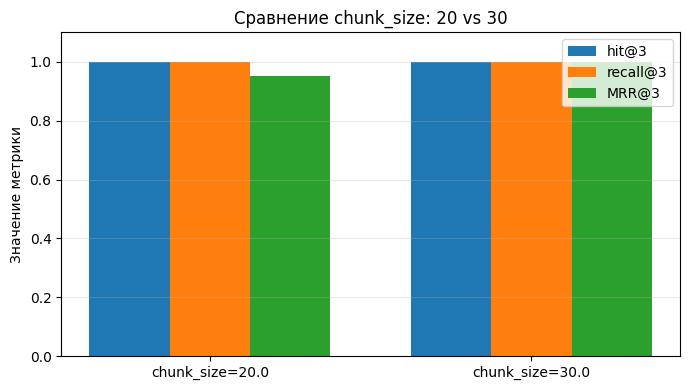

In [59]:
# Визуализация сравнения.
fig, ax = plt.subplots(figsize=(7, 4))

x = range(len(experiment_df))
width = 0.25

ax.bar([i - width for i in x], experiment_df["mean_hit@3"], width, label="hit@3")
ax.bar(list(x), experiment_df["mean_recall@3"], width, label="recall@3")
ax.bar([i + width for i in x], experiment_df["mean_MRR@3"], width, label="MRR@3")

ax.set_xticks(list(x))
ax.set_xticklabels([f'chunk_size={r["chunk_size"]}' for _, r in experiment_df.iterrows()])
ax.set_ylabel("Значение метрики")
ax.set_title("Сравнение chunk_size: 20 vs 30")
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Вывод по эксперименту:** в базе знаний оба варианта работают хорошо, потому что документы короткие и тематически чёткие. Оставляем `chunk_size=30` как основной вариант — он даёт чуть более контекстные фрагменты, что полезнее для последующего mini-RAG.

## 7. Обновление базы знаний и переиндексация

Добавление 3 новых документа в базу знаний:  
- спутник Европа (потенциальная жизнь);
- солнечные затмения;
- Титан (спутник Сатурна).

Сначала посмотрим, как baseline-retriever отвечает на вопросы по новым темам (ожидаемо плохо), а затем переиндексируем и сравним.

In [44]:
# Новые документы для обновления базы знаний.
new_documents: List[Dict[str, str]] = [
    {
        "doc_id": "doc_16",
        "title": "Европа – спутник Юпитера",
        "text": (
            "Европа – один из четырёх галилеевых спутников Юпитера. Под ледяной корой Европы "
            "скрывается глобальный океан жидкой воды. Наличие воды, энергии от приливного нагрева "
            "и химических элементов делает Европу одним из главных кандидатов на поиск внеземной жизни "
            "в Солнечной системе. Миссия Europa Clipper планирует детально изучить поверхность "
            "и подповерхностный океан спутника."
        ),
    },
    {
        "doc_id": "doc_17",
        "title": "Солнечные и лунные затмения",
        "text": (
            "Солнечное затмение происходит, когда Луна проходит между Землёй и Солнцем, "
            "закрывая солнечный диск. Лунное затмение происходит, когда Земля оказывается между "
            "Солнцем и Луной, и тень Земли падает на Луну. Полное солнечное затмение длится "
            "не более 7,5 минут. Затмения повторяются по циклу Сароса, который составляет "
            "примерно 18 лет и 11 дней."
        ),
    },
    {
        "doc_id": "doc_18",
        "title": "Титан – спутник Сатурна",
        "text": (
            "Титан – крупнейший спутник Сатурна и второй по размеру спутник в Солнечной системе. "
            "Титан обладает плотной азотной атмосферой с давлением на поверхности в 1,5 раза выше "
            "земного. На поверхности Титана обнаружены озёра и моря из жидкого метана и этана. "
            "Зонд Гюйгенс совершил посадку на Титан в 2005 году и передал первые снимки поверхности. "
            "Миссия Dragonfly планирует отправить дрон на Титан для изучения его поверхности."
        ),
    },
]

print(f"Новых документов: {len(new_documents)}")
display(pd.DataFrame(new_documents)[["doc_id", "title"]])

Новых документов: 3


,doc_id,title
0,doc_16,Европа – спутник Юпитера
1,doc_17,Солнечные и лунные затмения
2,doc_18,Титан – спутник Сатурна


In [45]:
# Запросы по темам новых документов — ДО обновления.
new_queries = [
    "Есть ли жидкая вода на Европе, спутнике Юпитера?",
    "Как происходит солнечное затмение?",
    "Какие озёра есть на Титане?",
]

display(Markdown("### Retrieval ДО обновления базы знаний"))
for q in new_queries:
    display(Markdown(f"**Запрос:** {q}"))
    display(search_chunks(q, artifacts=artifacts, top_k=3)[
        ["rank", "score", "doc_id", "title", "chunk_text"]
    ])

### Retrieval ДО обновления базы знаний

**Запрос:** Есть ли жидкая вода на Европе, спутнике Юпитера?

,rank,score,doc_id,title,chunk_text
0,1,0.6630,doc_08,Сатурн,"воде, если бы существовал достаточно большой о..."
1,2,0.6401,doc_07,Юпитер,"Пятно на Юпитере – это гигантский шторм, бушую..."
2,3,0.6169,doc_07,Юпитер,Юпитер – пятая планета от Солнца и крупнейшая ...


**Запрос:** Как происходит солнечное затмение?

,rank,score,doc_id,title,chunk_text
0,1,0.5563,doc_03,Венера,Вечерняя звезда или Утренняя звезда. В глубоко...
1,2,0.5420,doc_03,Венера,наблюдателя). Своей максимальной яркости Венер...
2,3,0.5282,doc_12,Кометы,Оорта или пояса Койпера. Знаменитая комета Гал...


**Запрос:** Какие озёра есть на Титане?

,rank,score,doc_id,title,chunk_text
0,1,0.5666,doc_08,Сатурн,"воде, если бы существовал достаточно большой о..."
1,2,0.4436,doc_10,Нептун,Нептун – восьмая и самая далёкая планета Солне...
2,3,0.4374,doc_08,Сатурн,до нескольких метров. Сатурн – второй по велич...


In [46]:
# Обновляем базу знаний и переиндексируем.
updated_documents = documents + new_documents
print(f"Документов после обновления: {len(updated_documents)}")

updated_artifacts = build_retriever(
    updated_documents,
    chunk_size=CHUNK_SIZE,
    overlap=OVERLAP,
    device=DEVICE,
)

print(f"Чанков после обновления: {len(updated_artifacts.chunks_df)}")

Документов после обновления: 18


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2632.08it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.
Бэкэнд: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Чанков после обновления: 68


In [47]:
# Те же запросы — ПОСЛЕ обновления.
display(Markdown("### Retrieval ПОСЛЕ обновления базы знаний"))
for q in new_queries:
    display(Markdown(f"**Запрос:** {q}"))
    display(search_chunks(q, artifacts=updated_artifacts, top_k=3)[
        ["rank", "score", "doc_id", "title", "chunk_text"]
    ])

### Retrieval ПОСЛЕ обновления базы знаний

**Запрос:** Есть ли жидкая вода на Европе, спутнике Юпитера?

,rank,score,doc_id,title,chunk_text
0,1,0.8075,doc_16,Европа – спутник Юпитера,Европа – один из четырёх галилеевых спутников ...
1,2,0.6630,doc_08,Сатурн,"воде, если бы существовал достаточно большой о..."
2,3,0.6550,doc_16,Европа – спутник Юпитера,нагрева и химических элементов делает Европу о...


**Запрос:** Как происходит солнечное затмение?

,rank,score,doc_id,title,chunk_text
0,1,0.7949,doc_17,Солнечные и лунные затмения,"Солнечное затмение происходит, когда Луна прох..."
1,2,0.5956,doc_17,Солнечные и лунные затмения,"Луной, и тень Земли падает на Луну. Полное сол..."
2,3,0.5563,doc_03,Венера,Вечерняя звезда или Утренняя звезда. В глубоко...


**Запрос:** Какие озёра есть на Титане?

,rank,score,doc_id,title,chunk_text
0,1,0.6274,doc_18,Титан – спутник Сатурна,"в 1,5 раза выше земного. На поверхности Титана..."
1,2,0.5666,doc_08,Сатурн,"воде, если бы существовал достаточно большой о..."
2,3,0.4579,doc_16,Европа – спутник Юпитера,Европа – один из четырёх галилеевых спутников ...


In [48]:
# Формальное сравнение до/после по расширенному benchmark.
extended_benchmark = benchmark_queries + [
    {"query_id": "q11", "query": "Есть ли жидкая вода на Европе, спутнике Юпитера?",
     "relevant_doc_ids": ["doc_16"]},
    {"query_id": "q12", "query": "Как происходит солнечное затмение?",
     "relevant_doc_ids": ["doc_17"]},
    {"query_id": "q13", "query": "Какие озёра есть на Титане?",
     "relevant_doc_ids": ["doc_18"]},
]

before_eval = evaluate_benchmark(extended_benchmark, artifacts=artifacts, top_k=3)
after_eval = evaluate_benchmark(extended_benchmark, artifacts=updated_artifacts, top_k=3)

# Сводка.
comparison_summary = pd.DataFrame({
    "metric": ["mean_hit@3", "mean_recall@3", "mean_MRR@3"],
    "before_update": [
        before_eval["hit@3"].mean(),
        before_eval["recall@3"].mean(),
        before_eval["MRR@3"].mean(),
    ],
    "after_update": [
        after_eval["hit@3"].mean(),
        after_eval["recall@3"].mean(),
        after_eval["MRR@3"].mean(),
    ],
})
comparison_summary["delta"] = comparison_summary["after_update"] - comparison_summary["before_update"]
display(comparison_summary)

# Детальное сравнение по каждому запросу.
comparison_detail = before_eval.merge(
    after_eval,
    on=["query_id", "query", "relevant_doc_ids"],
    suffixes=("_before", "_after"),
)
display(comparison_detail[[
    "query_id", "query",
    "predicted_doc_ids_before", "predicted_doc_ids_after",
    "hit@3_before", "hit@3_after",
]])

,metric,before_update,after_update,delta
0,mean_hit@3,0.769231,1.0,0.230769
1,mean_recall@3,0.769231,1.0,0.230769
2,mean_MRR@3,0.769231,1.0,0.230769


,query_id,query,predicted_doc_ids_before,predicted_doc_ids_after,hit@3_before,hit@3_after
0,q01,Какова температура на поверхности и в ядре Сол...,"doc_01, doc_09","doc_01, doc_09",1,1
1,q02,Почему на Меркурии такие большие перепады темп...,doc_02,doc_02,1,1
2,q03,Чем вызван парниковый эффект на Венере?,doc_03,doc_03,1,1
3,q04,Какой процент поверхности Земли покрыт водой?,"doc_04, doc_08","doc_04, doc_08",1,1
4,q05,Когда состоялась первая высадка людей на Луну?,doc_05,doc_05,1,1
5,q06,Какой самый большой вулкан в Солнечной системе...,"doc_06, doc_07","doc_06, doc_07",1,1
6,q07,Сколько спутников у Юпитера и какие из них сам...,doc_07,doc_07,1,1
7,q08,Из чего состоят кольца Сатурна?,"doc_08, doc_15","doc_08, doc_15",1,1
8,q09,Почему Плутон больше не считается планетой?,"doc_13, doc_15","doc_13, doc_15",1,1
9,q10,Какие аппараты Voyager изучали внешние планеты?,"doc_14, doc_01","doc_14, doc_01",1,1


## 8. Mini-RAG

Собираем простой mini-RAG-конвейер:  
**запрос → retrieval top-k → сборка контекста → генерация ответа → возврат с источниками.**

In [49]:
# Формирование контекста из результатов retrieval.
def build_context(query: str, artifacts: RetrievalArtifacts, top_k: int = 3) -> Tuple[str, pd.DataFrame]:
    retrieved = search_chunks(query, artifacts=artifacts, top_k=top_k)
    context_blocks = []
    for _, row in retrieved.iterrows():
        block = (
            f"[Источник: {row['doc_id']} | {row['title']} | score={row['score']:.4f}]\n"
            f"{row['chunk_text']}"
        )
        context_blocks.append(block)
    context = "\n\n".join(context_blocks)
    return context, retrieved

In [50]:

def split_into_sentences(text: str) -> List[str]:
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p.strip() for p in parts if p.strip()]


def generate_answer(query: str, context: str, max_sentences: int = 3) -> str:
    raw_lines = [line.strip() for line in context.splitlines() if line.strip()]
    content_lines = [line for line in raw_lines if not line.startswith("[Источник:")]

    sentence_pool = []
    for line in content_lines:
        sentence_pool.extend(split_into_sentences(line))

    if not sentence_pool:
        return "Не удалось найти ответ в базе знаний."

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    all_texts = [query] + sentence_pool
    tfidf_matrix = vectorizer.fit_transform(all_texts)
    similarities = (tfidf_matrix[1:] @ tfidf_matrix[0].T).toarray().ravel()

    top_indices = np.argsort(similarities)[::-1][:max_sentences]
    top_indices_sorted = sorted(top_indices)

    answer = " ".join(sentence_pool[i] for i in top_indices_sorted)
    return answer

In [51]:
def mini_rag_answer(
    query: str,
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
    max_sentences: int = 3,
) -> Dict[str, object]:
    context, retrieved = build_context(query, artifacts=artifacts, top_k=top_k)
    answer = generate_answer(query, context=context, max_sentences=max_sentences)

    return {
        "query": query,
        "answer": answer,
        "sources": retrieved,
        "context": context,
    }

In [52]:
# Примеры работы mini-RAG
rag_questions = [
    "Какая температура на поверхности Солнца?",
    "Почему Марс называют Красной планетой?",
    "Сколько спутников у Юпитера?",
    "Есть ли жидкая вода на спутнике Европа?",
    "Как происходит солнечное затмение?",
]

rag_results = []

for q in rag_questions:
    result = mini_rag_answer(q, artifacts=updated_artifacts, top_k=3)
    rag_results.append(result)

    display(Markdown(f"### Вопрос: {q}"))
    display(Markdown(f"**Ответ:** {result['answer']}"))
    display(Markdown("**Источники:**"))
    display(result["sources"][["rank", "score", "doc_id", "title"]])
    print()

### Вопрос: Какая температура на поверхности Солнца?

**Ответ:** Температура на поверхности Солнца составляет около 5500 градусов Цельсия, а в ядре достигает 15 Солнце обеспечивает энергию для жизни на Земле благодаря термоядерным реакциям, в ходе которых водород превращается в гелий. Масса Солнца составляет

**Источники:**

,rank,score,doc_id,title
0,1,0.7846,doc_01,Солнце
1,2,0.6457,doc_01,Солнце
2,3,0.5642,doc_02,Меркурий


### Вопрос: Почему Марс называют Красной планетой?

...

,rank,score,doc_id,title
0,1,0.7279,doc_16,Европа – спутник Юпитера
1,2,0.5898,doc_16,Европа – спутник Юпитера
2,3,0.5655,doc_08,Сатурн


### Вопрос: Как происходит солнечное затмение?

**Ответ:** Солнечное затмение происходит, когда Луна проходит между Землёй и Солнцем, закрывая солнечный диск. Полное солнечное затмение длится не более 7,5 минут. В глубокой древности Венера, как полагают, настолько разогрелась, что подобные земным океаны, которыми, как считается, она обладала, полностью испарились, оставив после себя пустынный пейзаж с

**Источники:**

,rank,score,doc_id,title
0,1,0.7949,doc_17,Солнечные и лунные затмения
1,2,0.5956,doc_17,Солнечные и лунные затмения
2,3,0.5563,doc_03,Венера


## 9. Анализ ошибок

In [53]:
# Пограничные и сложные запросы для анализа ошибок.
error_queries = [
    "Какая планета вращается в обратном направлении?",
    "Где в Солнечной системе можно найти жизнь?",
    "Чем отличаются газовые гиганты от ледяных?",
    "Какая погода на Нептуне?",
]

display(Markdown("### Анализ пограничных случаев"))

for q in error_queries:
    result = mini_rag_answer(q, artifacts=updated_artifacts, top_k=3)
    display(Markdown(f"---\n### Вопрос: {q}"))
    display(Markdown(f"**Ответ:** {result['answer']}"))
    display(result["sources"][["rank", "score", "doc_id", "title", "chunk_text"]])
    print()

### Анализ пограничных случаев

---
### Вопрос: Какая планета вращается в обратном направлении?

**Ответ:** Венера вращается в направлении, противоположном большинству планет, и один оборот вокруг своей оси занимает 243 земных дня – дольше, чем один оборот вокруг Солнца. Уран – седьмая планета от Солнца, относящаяся к ледяным гигантам. Внутренние планеты (Меркурий, Венера, Земля, Марс) – каменистые, а внешние (Юпитер, Сатурн, Уран, Нептун) – газовые и ледяные

,rank,score,doc_id,title,chunk_text
0,1,0.6593,doc_03,Венера,раз выше земного. Венера вращается в направлен...
1,2,0.6283,doc_09,Уран,"Уран – седьмая планета от Солнца, относящаяся ..."
2,3,0.5702,doc_15,Формирование Солнечной системы,"Солнце, а из оставшегося вещества – протоплане..."


---
### Вопрос: Где в Солнечной системе можно найти жизнь?

...

**Ответ:** (Юпитер, Сатурн, Уран, Нептун) – газовые и ледяные гиганты. силой, в холодную пору на планету выпадают заряженные от светила радиоактивные частицы, которые сохраняют свой вид в виде серы и железного снега. Крупнейший

,rank,score,doc_id,title,chunk_text
0,1,0.6949,doc_15,Формирование Солнечной системы,"(Юпитер, Сатурн, Уран, Нептун) – газовые и лед..."
1,2,0.5588,doc_02,Меркурий,"силой, в холодную пору на планету выпадают зар..."
2,3,0.5381,doc_08,Сатурн,до нескольких метров. Сатурн – второй по велич...


---
### Вопрос: Какая погода на Нептуне?

**Ответ:** поэтому он как бы лежит на боку. Поверхность Меркурия покрыта кратерами и напоминает лунную. Меркурий исследовался

,rank,score,doc_id,title,chunk_text
0,1,0.4802,doc_09,Уран,слоёв атмосферы Урана составляет около минус 2...
1,2,0.4766,doc_09,Уран,поэтому он как бы лежит на боку. Атмосфера Ура...
2,3,0.3889,doc_02,Меркурий,огромны: от минус 180 градусов ночью до плюс 4...


### Комментарии к пограничным случаям

1. **«Какая планета вращается в обратном направлении?»** — для такой маленькой модели нет конкретного названия планеты, будет вытаскивать данные по всем планетам, поэтому retrieval может вытащить неточные фрагменты. Проблема: косвенная формулировка вопроса.

2. **«Где в Солнечной системе можно найти жизнь?»** — довльно-таки сложный запрос. Релевантны и Земля, и Европа. Retrieval может не покрыть оба документа в top-3.

3. **«Чем отличаются газовые гиганты от ледяных?»** — ответ рассредоточен по документам про Юпитер, Сатурн, Уран и Нептун. Mini-RAG ограничен контекстом из top-3 чанков и не может собрать полный ответ.

4. **«Какая погода на Нептуне?»** — слово «погода» отсутствует в тексте документа, вместо него используется «ветры». Это пример лексического несоответствия, который dense embeddings могут частично преодолеть.

## 10. Сохранение артефактов

In [54]:
os.makedirs("artifacts", exist_ok=True)

# 1. retrieval_eval.csv
eval_for_save = evaluate_benchmark(benchmark_queries, artifacts=artifacts, top_k=3)
eval_for_save.to_csv("artifacts/retrieval_eval.csv", index=False)
print("Сохранено: artifacts/retrieval_eval.csv")
display(eval_for_save.head())

# 2. rag_examples.csv
rag_examples_rows = []
for result in rag_results:
    sources_str = ", ".join(result["sources"]["doc_id"].tolist())
    rag_examples_rows.append({
        "question": result["query"],
        "answer": result["answer"],
        "retrieved_sources": sources_str,
    })
rag_examples_df = pd.DataFrame(rag_examples_rows)
rag_examples_df.to_csv("artifacts/rag_examples.csv", index=False)
print("\nСохранено: artifacts/rag_examples.csv")
display(rag_examples_df.head())

# 3. retrieval_before_after_update.csv
before_after_rows = []
for row in extended_benchmark:
    before_result = search_chunks(row["query"], artifacts=artifacts, top_k=3)
    after_result = search_chunks(row["query"], artifacts=updated_artifacts, top_k=3)
    before_sources = ", ".join(unique_doc_order(before_result))
    after_sources = ", ".join(unique_doc_order(after_result))
    before_after_rows.append({
        "query": row["query"],
        "before_retrieved_sources": before_sources,
        "after_retrieved_sources": after_sources,
        "changed": before_sources != after_sources,
    })
before_after_df = pd.DataFrame(before_after_rows)
before_after_df.to_csv("artifacts/retrieval_before_after_update.csv", index=False)
print("\nСохранено: artifacts/retrieval_before_after_update.csv")
display(before_after_df)

Сохранено: artifacts/retrieval_eval.csv


,query_id,query,relevant_doc_ids,predicted_doc_ids,hit@3,recall@3,MRR@3,first_relevant_rank
0,q01,Какова температура на поверхности и в ядре Сол...,doc_01,"doc_01, doc_09",1,1.0,1.0,1
1,q02,Почему на Меркурии такие большие перепады темп...,doc_02,doc_02,1,1.0,1.0,1
2,q03,Чем вызван парниковый эффект на Венере?,doc_03,doc_03,1,1.0,1.0,1
3,q04,Какой процент поверхности Земли покрыт водой?,doc_04,"doc_04, doc_08",1,1.0,1.0,1
4,q05,Когда состоялась первая высадка людей на Луну?,doc_05,doc_05,1,1.0,1.0,1



Сохранено: artifacts/rag_examples.csv


,question,answer,retrieved_sources
0,Какая температура на поверхности Солнца?,Температура на поверхности Солнца составляет о...,"doc_01, doc_01, doc_02"
1,Почему Марс называют Красной планетой?,"Марс – четвёртая планета от Солнца, известная ...","doc_06, doc_06, doc_14"
2,Сколько спутников у Юпитера?,"У Юпитера более 90 известных спутников, среди ...","doc_07, doc_07, doc_11"
3,Есть ли жидкая вода на спутнике Европа?,Европа – один из четырёх галилеевых спутников ...,"doc_16, doc_16, doc_08"
4,Как происходит солнечное затмение?,"Солнечное затмение происходит, когда Луна прох...","doc_17, doc_17, doc_03"



Сохранено: artifacts/retrieval_before_after_update.csv


,query,before_retrieved_sources,after_retrieved_sources,changed
0,Какова температура на поверхности и в ядре Сол...,"doc_01, doc_09","doc_01, doc_09",False
1,Почему на Меркурии такие большие перепады темп...,doc_02,doc_02,False
2,Чем вызван парниковый эффект на Венере?,doc_03,doc_03,False
3,Какой процент поверхности Земли покрыт водой?,"doc_04, doc_08","doc_04, doc_08",False
4,Когда состоялась первая высадка людей на Луну?,doc_05,doc_05,False
5,Какой самый большой вулкан в Солнечной системе...,"doc_06, doc_07","doc_06, doc_07",False
6,Сколько спутников у Юпитера и какие из них сам...,doc_07,doc_07,False
7,Из чего состоят кольца Сатурна?,"doc_08, doc_15","doc_08, doc_15",False
8,Почему Плутон больше не считается планетой?,"doc_13, doc_15","doc_13, doc_15",False
9,Какие аппараты Voyager изучали внешние планеты?,"doc_14, doc_01","doc_14, doc_01",False
